# Project Milestone One: Gathering your Team, Understanding the Problem,  Exploring the Data

#### Due: Midnight on March 29th (with 2-hour grace period)  

#### There will be no late period on this homework, as we need to start manual grading immediately! 



### What We Will Do in This Milestone Assignment

1. You will convene your team and fill out the Team Contract (in the Homework Repo), to be submitted to Gradescope.
2. You must select a team leader for the purpose of submitting this notebook, after the team collaborates to complete the assignment. This <a href=https://guides.gradescope.com/hc/en-us/articles/21863861823373-Adding-Group-Members-to-a-Submission>link</a> describes how to add group members to your leader's submission. 
3. At the conclusion of your work on this Milestone, you will complete an Individual Evaluation of your team's work (in the Homework Repo) and upload it *individually* to Gradescope.
4. We will follow a simplified version of the **Machine Learning Project Checklist** in Appendix A in our textbook *Hands-On Machine Learning* (pp.779):  

>Part 1:	Frame the problem and look at the big picture  
Part 2: Download and perform preliminary exploration of the data  
Part 3: Clean the Data: Drop, Impute, and Encode   
Part 4: Explore Feature Relationships  
Part 5: Investigate Feature Engineering options to better expose the underlying data patterns  

### The Dataset

All teams will use the same dataset. It is a smaller version of the Zillow housing dataset that was used in the
Zillow Million Dollar Prize which ran on Kaggle in 2017 (sorry, the contest is closed, so you can't win any money
with this project!).  We will try to predict the assessed tax value (`'taxvaluedollarcnt'`) of the property from a large collection
of descriptors. Some features are closely related and some are obviously useless.  There are potential outliers and also quite a few missing values. 

This is a good example of a dataset which has not been predigested for you on Kaggle, and should give you a good chance to
try all the various tools in your toolbox!


In [158]:
# =============================
# Useful Imports
# =============================

# Standard Libraries
import os
import time
import math
import io
import zipfile
import requests
from urllib.parse import urlparse
from itertools import chain, combinations

# Data Science Libraries
import numpy as np
import pandas as pd
import seaborn as sns

# Visualization
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.ticker as mticker  # Optional: Format y-axis labels as dollars

# Scikit-learn (Machine Learning)
from sklearn.model_selection import (
    train_test_split, 
    cross_val_score, 
    GridSearchCV, 
    RandomizedSearchCV, 
    RepeatedKFold
)
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.feature_selection import SequentialFeatureSelector, f_regression, SelectKBest
from sklearn.datasets import make_regression
from sklearn.ensemble import BaggingRegressor, RandomForestRegressor, GradientBoostingRegressor

# Kaggle and Progress Tracking
from tqdm import tqdm

# =============================
# Global Variables
# =============================
random_state = 42

# =============================
# Utility Functions
# =============================

# Format y-axis labels as dollars with commas (optional)
def dollar_format(x, pos):
    return f'${x:,.0f}'

# Convert seconds to HH:MM:SS format
def format_hms(seconds):
    return time.strftime("%H:%M:%S", time.gmtime(seconds))



## Prelude: Download the Zillow Housing Dataset 

The code cell below will load the dataset for you.    

> **Notice that before downloading, this cell first checks whether the files already exist.** 

For a detailed description of the dataset features, please refer to  **Appendix 1** below. 

**Note:** Do **not** perform a train/test split for this milestone (unlike HOML suggests), since you need to do the split **after** any data preparation and feature engineering. You can wait until Milestone 2 to do the split. 

In [159]:

url = "https://www.cs.bu.edu/fac/snyder/cs505/Data/zillow_dataset.csv"

filename = os.path.basename(urlparse(url).path)

if not os.path.exists(filename):
    try:
        print("Downloading the file...")
        response = requests.get(url)
        response.raise_for_status()  # Raise an error for bad status codes
        with open(filename, "wb") as f:
            f.write(response.content)
        print("File downloaded successfully.")
    except requests.exceptions.RequestException as e:
        print(f"Error downloading the file: {e}")
else:
    print("File already exists. Skipping download.")

df = pd.read_csv(filename)

File already exists. Skipping download.


## Part 1: Frame the problem and look at the big picture [3 pts]

This part is a bit vague, since this project is not taking place in an actual business, but for the sake of exercizing all the steps, **pretend** that you are working at Zillow as a data analyst and are given this dataset and asked to
- Analyze and understand the data; 
- Create a regression model;
- Give a presentation to the marketing team about your results.  

#### **1 Discussion:** 

AFTER doing your EDA, come back and answer each of the following 3 questions in a *concise and informative paragraph between the lines;* you may wish to use your own business or home-buying experience, or to do some online research about the issues before you propose your ideas. (Don't stress about this, but *humor your professor and give it your best shot!*)


**1.1:**  What is the objective of this project in business terms?

The objective of this project is to build a regression model that can accurately predict the **tax assessed** value of a residential property in Los Angeles County. This will be done using the data available in the dataset provided by zillow, and will help buyers and lenders both make informaed decisions about the assessed values of properties and the true market values.

**1.2:**  How will your solution be used?

The model will be deployed as part of Zillow's valuation system, and will give property value estimates, or 'Zestimates', without the need for a mnaual appraisal. It can also be leveraged internally to indentify what properties are being overvaled, or undervalued, and figure out what is causing the incosistencies in the model, and them be used to improve prdictions. When a property is posted it will automatically be appraised by the system and assigned a value

**1.3:**  How should success (or failure) be measured?

The models usefullness should be primarily measured by the Mean Absolute Error, since this value is highly interpretable as it is measured in dollars, and is not overly sensitive to outliers. A target MAE can be set to assess model performance, for example we could consider an MAE of under $100,000 to be accurate. The model should also generalize well across zip regions, so that expensive neighborhoods do not skew the outcomes too much.


## Part 2: Download and perform preliminary exploration of the data [4 pts]

### Part 2.A: Load the data into a dataframe and study each feature/column and its characteristics:
- Name
- Type (categorical, int/float, text, etc.)
- Apparent usefulness for the task
- Approximate % of missing values
- How many unique values

**Note:** The **target** is the last column `'taxvaluedollarcnt'` -- pay particular attention to this during the EDA process. 
  
Hint: Just use `.head()`, `.info()`, and `.nunique()`.

In [160]:
df.head()

,parcelid,airconditioningtypeid,architecturalstyletypeid,basementsqft,bathroomcnt,bedroomcnt,buildingclasstypeid,buildingqualitytypeid,calculatedbathnbr,decktypeid,...,yardbuildingsqft17,yardbuildingsqft26,yearbuilt,numberofstories,fireplaceflag,assessmentyear,taxdelinquencyflag,taxdelinquencyyear,censustractandblock,taxvaluedollarcnt
0,14297519,NaN,NaN,NaN,3.5,4.0,NaN,NaN,3.5,NaN,...,NaN,NaN,1998.0,NaN,NaN,2016.0,NaN,NaN,6.059063e+13,1023282.0
1,17052889,NaN,NaN,NaN,1.0,2.0,NaN,NaN,1.0,NaN,...,NaN,NaN,1967.0,1.0,NaN,2016.0,NaN,NaN,6.111001e+13,464000.0
2,14186244,NaN,NaN,NaN,2.0,3.0,NaN,NaN,2.0,NaN,...,NaN,NaN,1962.0,1.0,NaN,2016.0,NaN,NaN,6.059022e+13,564778.0
3,12177905,NaN,NaN,NaN,3.0,4.0,NaN,8.0,3.0,NaN,...,NaN,NaN,1970.0,NaN,NaN,2016.0,NaN,NaN,6.037300e+13,145143.0
4,10887214,1.0,NaN,NaN,3.0,3.0,NaN,8.0,3.0,NaN,...,NaN,NaN,1964.0,NaN,NaN,2016.0,NaN,NaN,6.037124e+13,119407.0


In [161]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 77613 entries, 0 to 77612
Data columns (total 55 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   parcelid                      77613 non-null  int64  
 1   airconditioningtypeid         25007 non-null  float64
 2   architecturalstyletypeid      207 non-null    float64
 3   basementsqft                  50 non-null     float64
 4   bathroomcnt                   77579 non-null  float64
 5   bedroomcnt                    77579 non-null  float64
 6   buildingclasstypeid           15 non-null     float64
 7   buildingqualitytypeid         49809 non-null  float64
 8   calculatedbathnbr             76963 non-null  float64
 9   decktypeid                    614 non-null    float64
 10  finishedfloor1squarefeet      6037 non-null   float64
 11  calculatedfinishedsquarefeet  77378 non-null  float64
 12  finishedsquarefeet12          73923 non-null  float64
 13  f

In [162]:
df.nunique()

parcelid                        77414
airconditioningtypeid               5
architecturalstyletypeid            5
basementsqft                       43
bathroomcnt                        22
bedroomcnt                         16
buildingclasstypeid                 2
buildingqualitytypeid              12
calculatedbathnbr                  21
decktypeid                          1
finishedfloor1squarefeet         1787
calculatedfinishedsquarefeet     4972
finishedsquarefeet12             4868
finishedsquarefeet13               13
finishedsquarefeet15             1724
finishedsquarefeet50             1807
finishedsquarefeet6               350
fips                                3
fireplacecnt                        5
fullbathcnt                        13
garagecarcnt                       14
garagetotalsqft                   839
hashottuborspa                      1
heatingorsystemtypeid              10
latitude                        64038
longitude                       62461
lotsizesquar

In [163]:
categorical_features = df.select_dtypes(include=['object']).columns.to_list()

In [164]:
missing = (df.isnull().mean() * 100).sort_values(ascending=False).to_frame()
missing_more_than_60 = missing[missing>60].T.columns.to_list()

missing_more_than_60

['buildingclasstypeid',
 'finishedsquarefeet13',
 'storytypeid',
 'basementsqft',
 'yardbuildingsqft26',
 'fireplaceflag',
 'architecturalstyletypeid',
 'typeconstructiontypeid',
 'finishedsquarefeet6',
 'pooltypeid10',
 'decktypeid',
 'poolsizesum',
 'pooltypeid2',
 'hashottuborspa',
 'yardbuildingsqft17',
 'taxdelinquencyflag',
 'taxdelinquencyyear',
 'finishedsquarefeet15',
 'finishedsquarefeet50',
 'finishedfloor1squarefeet',
 'fireplacecnt',
 'threequarterbathnbr',
 'pooltypeid7',
 'poolcnt',
 'numberofstories',
 'airconditioningtypeid',
 'garagetotalsqft',
 'garagecarcnt',
 'regionidneighborhood',
 'heatingorsystemtypeid',
 'buildingqualitytypeid',
 'propertyzoningdesc',
 'unitcnt',
 'lotsizesquarefeet',
 'finishedsquarefeet12',
 'regionidcity',
 'fullbathcnt',
 'calculatedbathnbr',
 'yearbuilt',
 'censustractandblock',
 'calculatedfinishedsquarefeet',
 'regionidzip',
 'taxvaluedollarcnt',
 'roomcnt',
 'regionidcounty',
 'rawcensustractandblock',
 'propertylandusetypeid',
 'prope

#### **2.A Discussion:** Answer the following questions.

**2.A.1:**  Which features are categorical?

In [165]:
print(f"The following features from the dataset are categorical: {categorical_features} ")

The following features from the dataset are categorical: ['hashottuborspa', 'propertycountylandusecode', 'propertyzoningdesc', 'fireplaceflag', 'taxdelinquencyflag'] 


**2.A.2:**  Are there any features which appear at first glance to be **useless** for the business purpose of this project and should be deleted?  Give examples and describe your reasoning briefly.

At first glance I would find the following features to be useless:

| Feature Name | Description | Reasoning |
|---|---|---|
**parcelid**| Unique identifier for the property parcel.| unique identifier will have no affect on price, it is only used for indentification. Serves no purpose in modeling
**fips**| Federal Information Processing Standards code, uniquely identifying counties and county equivalents.| Another unncessary identifier - there are other features that identify county
**rawcensustractandblock**| Unprocessed census tract and block identifier.| meant for collecting census data, so the identifiers likely will have no impact on price
**threequarterbathnbr**| Number of 3/4 bathrooms (typically includes a shower but no tub).| Seems too specific, there are other features that will capture total amount of bathrooms
**taxdelinquencyflag**| Indicates whether the property’s taxes are delinquent. Often “Y” if taxes are past due; otherwise null/empty.| Does not seem like it would affect assessed value, it is only measuring if it was paid or not
**taxdelinquencyyear**| The year in which the property’s taxes became delinquent.| same as above.


**2.A.3:**  Are there any features which appear to be **useless** because of the percentage of missing values?  If so, give an example. 

In [166]:
print(f"The following features are missing more than 60% of their values and should be investifated for usefullness {missing_more_than_60}")

The following features are missing more than 60% of their values and should be investifated for usefullness ['buildingclasstypeid', 'finishedsquarefeet13', 'storytypeid', 'basementsqft', 'yardbuildingsqft26', 'fireplaceflag', 'architecturalstyletypeid', 'typeconstructiontypeid', 'finishedsquarefeet6', 'pooltypeid10', 'decktypeid', 'poolsizesum', 'pooltypeid2', 'hashottuborspa', 'yardbuildingsqft17', 'taxdelinquencyflag', 'taxdelinquencyyear', 'finishedsquarefeet15', 'finishedsquarefeet50', 'finishedfloor1squarefeet', 'fireplacecnt', 'threequarterbathnbr', 'pooltypeid7', 'poolcnt', 'numberofstories', 'airconditioningtypeid', 'garagetotalsqft', 'garagecarcnt', 'regionidneighborhood', 'heatingorsystemtypeid', 'buildingqualitytypeid', 'propertyzoningdesc', 'unitcnt', 'lotsizesquarefeet', 'finishedsquarefeet12', 'regionidcity', 'fullbathcnt', 'calculatedbathnbr', 'yearbuilt', 'censustractandblock', 'calculatedfinishedsquarefeet', 'regionidzip', 'taxvaluedollarcnt', 'roomcnt', 'regionidcount

**2.A.4:**  Are there any features which appear to be **useless** because of the number of unique values?  If so, give an example. 

- propertyzoningdesc has 1907 unique descriptions that seem meaningless and would probably add noise to a model
- assessmentyear has only 1 unique value, so all values were assessed in the same year thus making this feature uselss

### Part 2.B: Exploratory Data Analysis (EDA) -- Feature-Level Visualization  

- To get an overview, generate histograms for all features using `df.hist()`  (Hint: increase the figsize and set the layout to `(-1,m)` to get  `m` columns and as many rows as necessary.)
- Generate individual visualizations for the **target and three (3)** other interesting-looking features in the dataset (i.e., a total of 4):  
    - Use appropriate plot types (e.g., histograms and boxplots for numerical features, bar plots for categorical features) to understand distributions and identify potential outliers for these three.
    - Use as many code cells as you need, and give comments describing what each cell does.
    - Answer the discussion question posed (you should choose 3 features for which you can say something interesting in the discussion).  

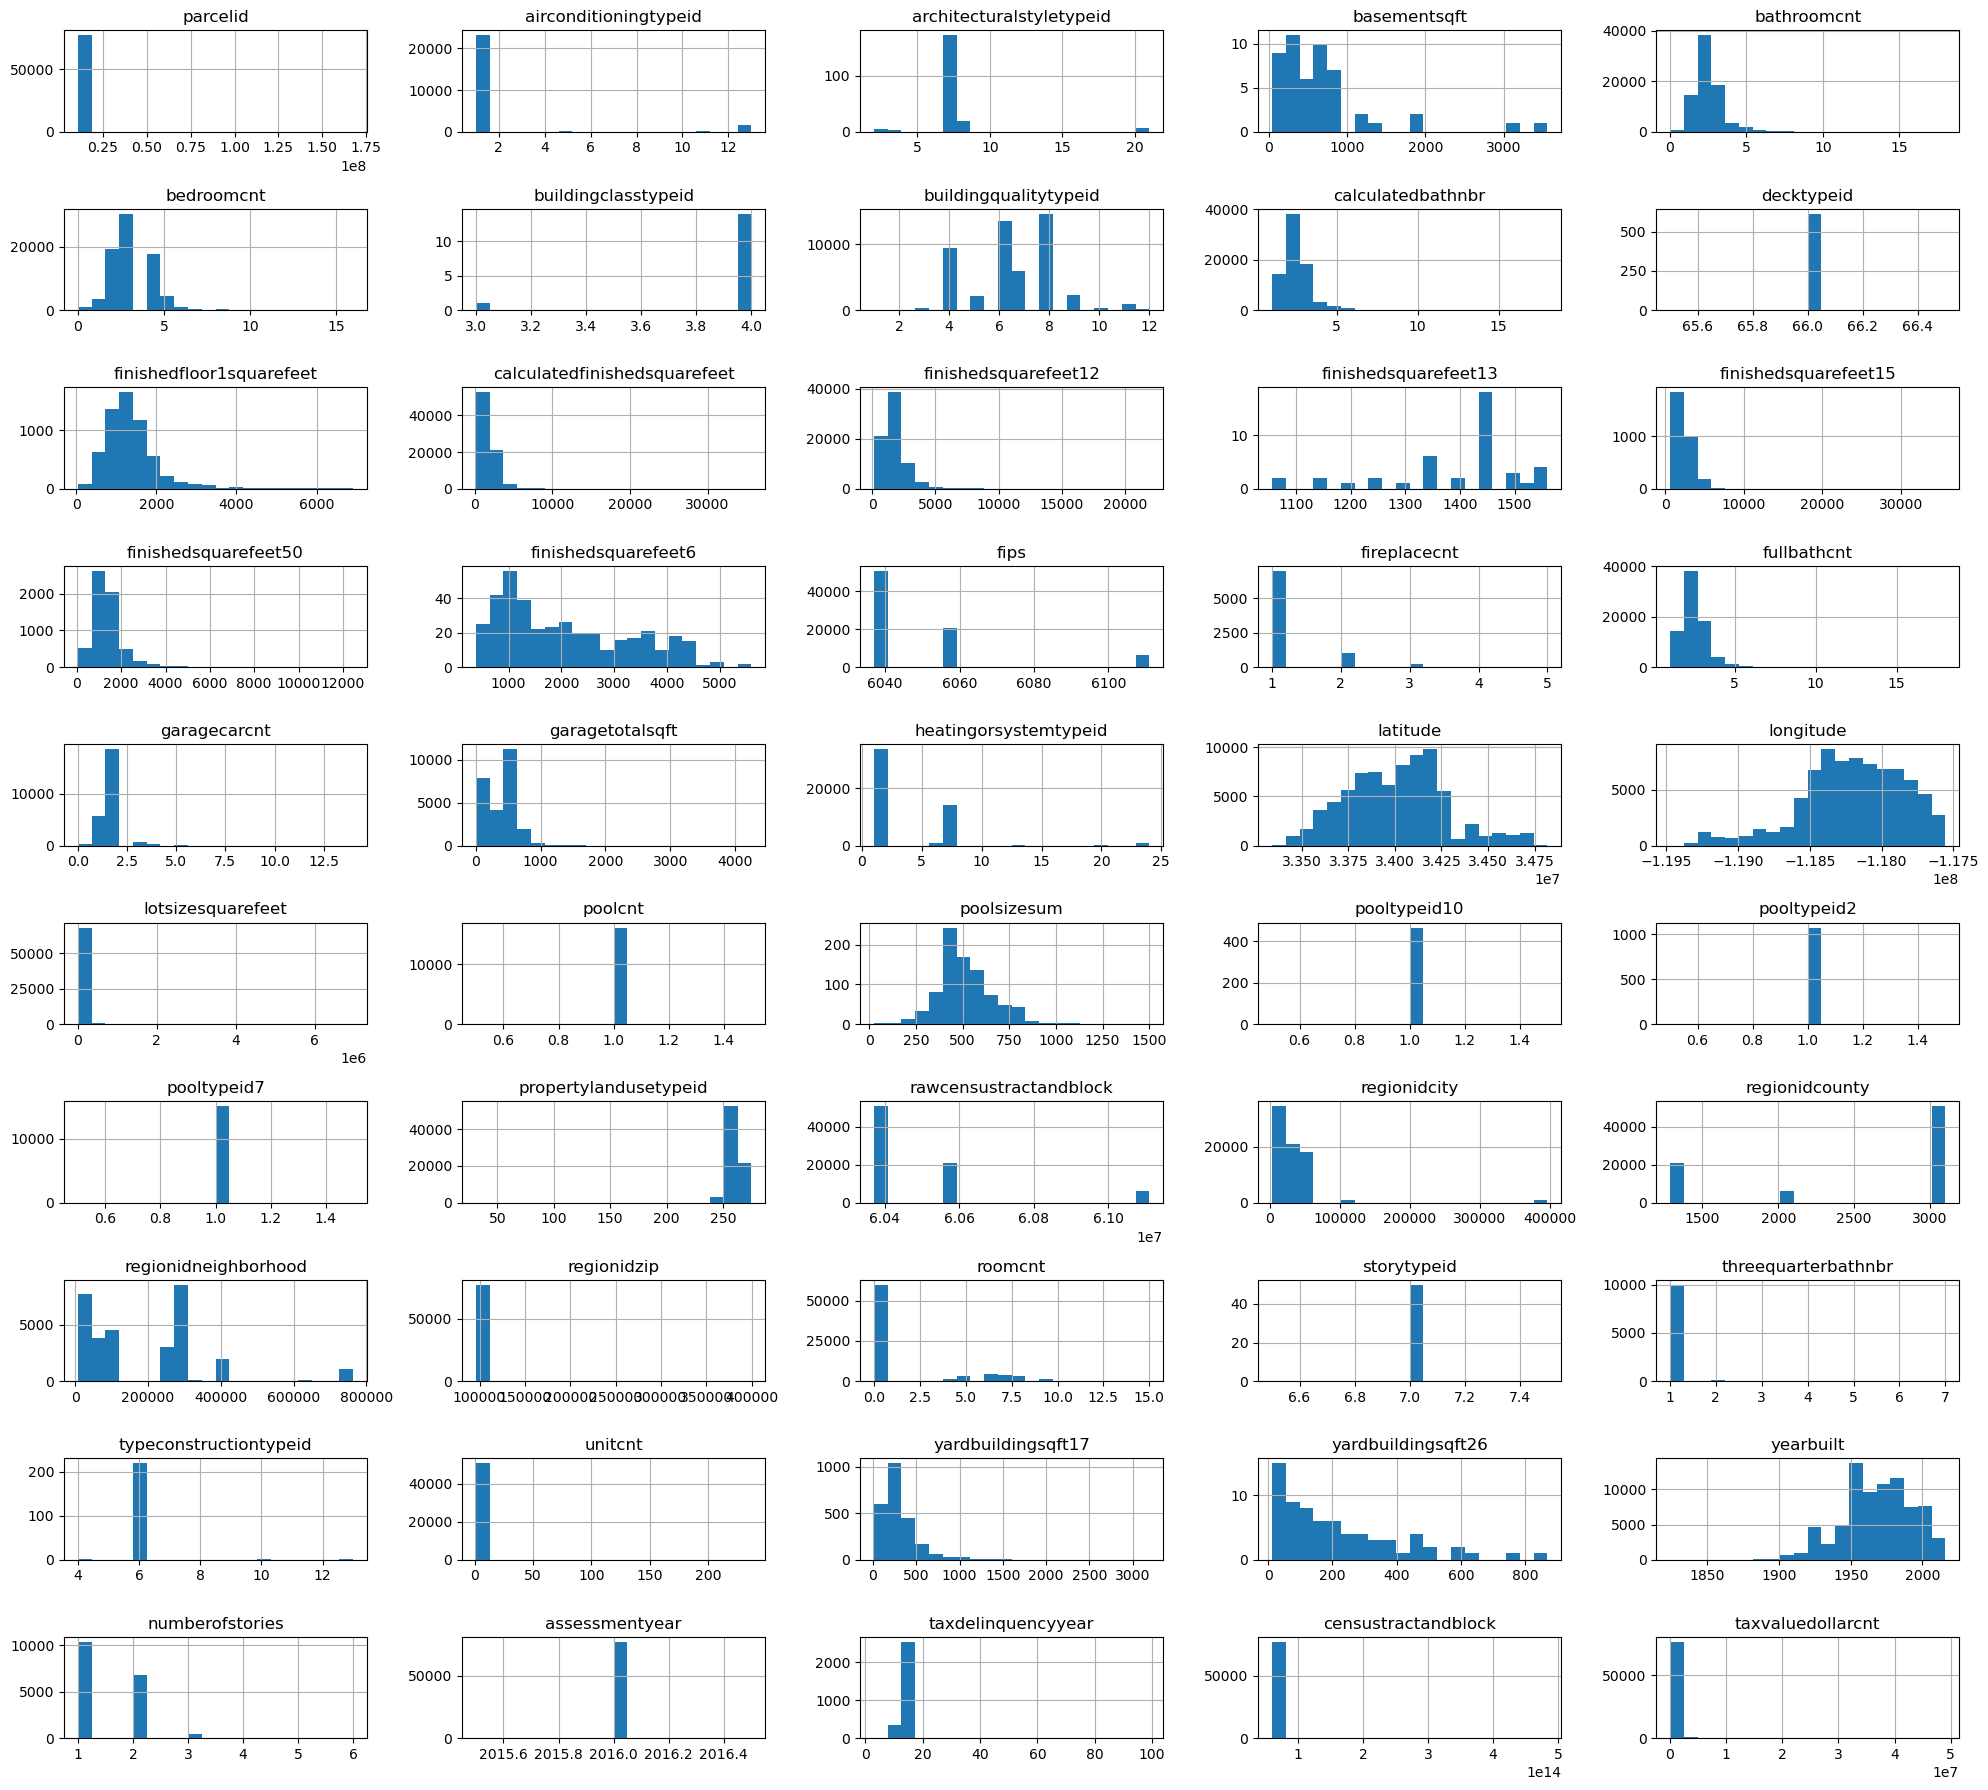

In [167]:
columns = 5
df.hist(figsize=(20,18), layout=(-1,columns), bins=20)

plt.tight_layout()
plt.show()

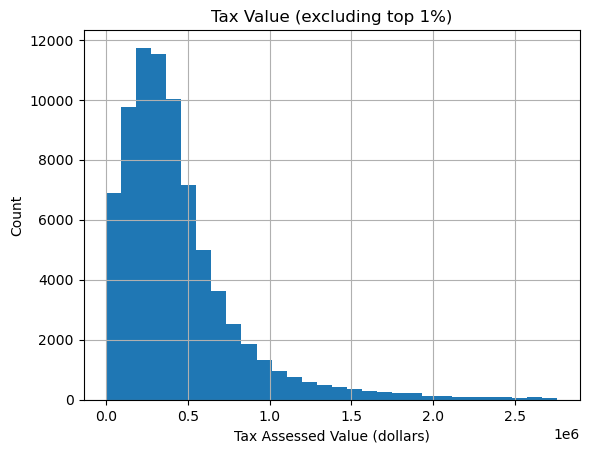

In [168]:
#plotting assessed tax value (target) without the top 1% so that it is easier to visualize

df['taxvaluedollarcnt'].hist(bins=30, range=(0, df['taxvaluedollarcnt'].quantile(0.99)))
plt.title('Tax Value (excluding top 1%)')
plt.xlabel("Tax Assessed Value (dollars)")
plt.ylabel("Count")
plt.show()


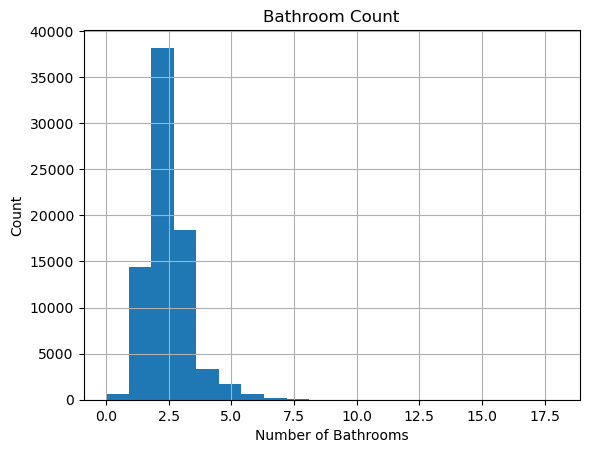

In [169]:
df['bathroomcnt'].hist(bins = 20)

plt.title("Bathroom Count")
plt.ylabel("Count")
plt.xlabel("Number of Bathrooms")
plt.show()

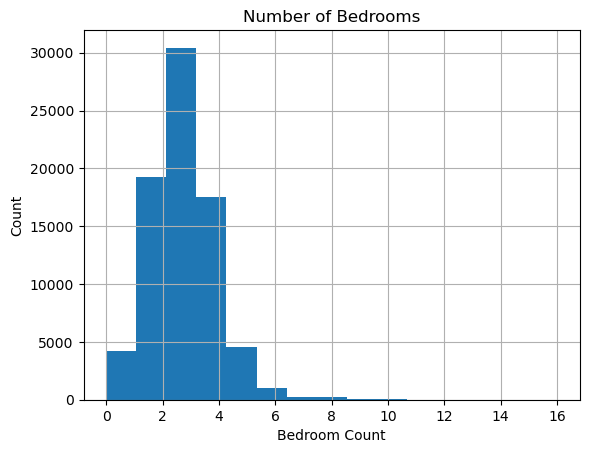

In [170]:
df['bedroomcnt'].hist(bins=15)

plt.title("Number of Bedrooms")
plt.xlabel("Bedroom Count")
plt.ylabel("Count")
plt.show()

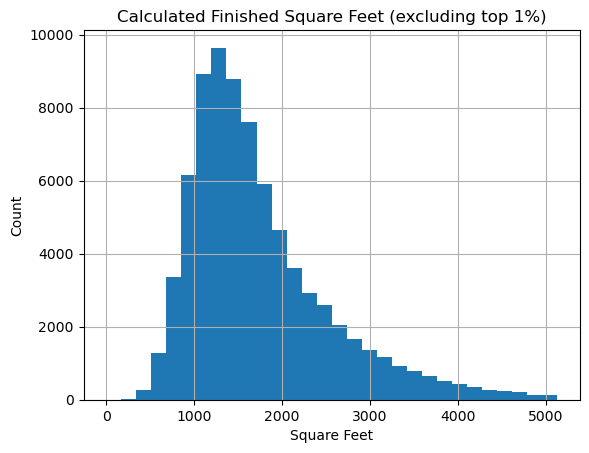

In [171]:
#plotting total living square feet without the top 1% so that it is easier to visualize

df['calculatedfinishedsquarefeet'].hist(bins=30, range=(0, df['calculatedfinishedsquarefeet'].quantile(0.99)))

plt.title("Calculated Finished Square Feet (excluding top 1%)")
plt.xlabel("Square Feet")
plt.ylabel("Count")
plt.show()

#### **2.B Discussion:** Describe in a paragraph what you learned in your detailed examination of the features you explored:
- What is the distribution (normal, exponential, etc.) if any?
- Any problems (e.g., outliers, any odd characteristics)?
- Anything else interesting? Why did you choose it?


- taxvaluedollarcnt: Has a right skewed distribution, there is a long tail toward high value properties. This is the target variable for this problem, and we may want to log transform it for regression
- bathroomcnt: Chosen as it is commonly discussed when talking about the size of the house. It has a right skewed distribution, where most houses have 2-3 and then drops off sharply after that
- bedroomcnt: Similar to bathroom it is a common measure when discussing house size. Also Right skewed and peaks around 3-4 bedrooms. Some were reported as 0 which could be a potential problem for modeling.
- calculatedfinishedsquarefeet: Again right skewed with a long tail. Moderate house sizes around 1200-1500 sq ft. Generally speaking, the bigger a house is the more expensive it will be, which is why this was chosen.

## Part 3:  Clean the Data: Drop, Impute, and Encode [6 pts]



**Important Notes:**
- You should review your Homework 4 before doing this section!
- Create new names for modified data at each stage to avoid problems with global variables.
- Whenever possible, write functions for all data transformations you apply, for these reasons:
    - So you can easily prepare the data the next time you get a fresh dataset
    - So you can apply these transformations in future projects
    - To clean and prepare new data instances once your solution is live
    - To make it easy to treat your preparation choices as hyperparameters
    - [To apply the same transformations to your test set if train/test split already done -- not applicable here]

### Part 3.A: Drop features you judge to be unsuitable for the regression task

Your call, based on any research you can do to understand the feature (hopefully IRL you would have a domain expert to help with this, but do your best).   

Note: Do not drop features because of too many missing values, that's the next task! 

In [172]:
features_to_drop = ['parcelid','calculatedbathnbr', 'fips', 'poolsizesum', 'pooltypeid10', 
                    'pooltypeid2', 'pooltypeid7', 'rawcensustractandblock', 'propertycountylandusecode',
                      'propertyzoningdesc', 'regionidcity', 'regionidcounty', 'threequarterbathnbr', 'assessmentyear', 'taxdelinquencyflag', 'taxdelinquencyyear',
                        'censustractandblock', 'finishedfloor1squarefeet','finishedsquarefeet12', 'finishedsquarefeet13', 'finishedsquarefeet15', 'finishedsquarefeet50',
                         'finishedsquarefeet6', 'fullbathcnt', 'garagetotalsqft','regionidneighborhood']
df_dropped = df.drop(columns=features_to_drop)

df_dropped

,airconditioningtypeid,architecturalstyletypeid,basementsqft,bathroomcnt,bedroomcnt,buildingclasstypeid,buildingqualitytypeid,decktypeid,calculatedfinishedsquarefeet,fireplacecnt,...,roomcnt,storytypeid,typeconstructiontypeid,unitcnt,yardbuildingsqft17,yardbuildingsqft26,yearbuilt,numberofstories,fireplaceflag,taxvaluedollarcnt
0,NaN,NaN,NaN,3.5,4.0,NaN,NaN,NaN,3100.0,NaN,...,0.0,NaN,NaN,NaN,NaN,NaN,1998.0,NaN,NaN,1023282.0
1,NaN,NaN,NaN,1.0,2.0,NaN,NaN,NaN,1465.0,1.0,...,5.0,NaN,NaN,NaN,NaN,NaN,1967.0,1.0,NaN,464000.0
2,NaN,NaN,NaN,2.0,3.0,NaN,NaN,NaN,1243.0,NaN,...,6.0,NaN,NaN,NaN,NaN,NaN,1962.0,1.0,NaN,564778.0
3,NaN,NaN,NaN,3.0,4.0,NaN,8.0,NaN,2376.0,NaN,...,0.0,NaN,NaN,1.0,NaN,NaN,1970.0,NaN,NaN,145143.0
4,1.0,NaN,NaN,3.0,3.0,NaN,8.0,NaN,1312.0,NaN,...,0.0,NaN,NaN,1.0,NaN,NaN,1964.0,NaN,NaN,119407.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
77608,1.0,NaN,NaN,3.0,3.0,NaN,8.0,NaN,1741.0,NaN,...,0.0,NaN,NaN,1.0,NaN,NaN,1980.0,NaN,NaN,379000.0
77609,NaN,NaN,NaN,2.0,2.0,NaN,6.0,NaN,1286.0,NaN,...,0.0,NaN,NaN,1.0,NaN,NaN,1940.0,NaN,NaN,354621.0
77610,NaN,NaN,NaN,2.0,4.0,NaN,NaN,NaN,1612.0,1.0,...,7.0,NaN,NaN,NaN,656.0,NaN,1964.0,1.0,NaN,67205.0
77611,1.0,NaN,NaN,1.0,3.0,NaN,4.0,NaN,1032.0,NaN,...,0.0,NaN,NaN,1.0,NaN,NaN,1954.0,NaN,NaN,49546.0


#### **3.A Discussion:** Justify in a paragraph your decisions about which features to drop. 


Some of these features were dropped because they are unique identifiers, such as the parcelid, or the censustractandblock features. These would not add any value to a model as they have no inherent meaning. Calculatedbathnbr was droppped becuase it did not seem to differ significantly from the bathroomcnt feature, but had more missing values. Other location information such as city and county were dropped, becuase the zip code was kept, and the zip code contains the same information. Assessment year was dropped because they are all 2016, so it has no value. Multiple square footage features dropped, the only one we care about is total living area square feet.

The biggest driving factor for removing features that will likely have high multicollinearity. It is obvious that if there are more bathrooms than the fullbathcount will also increase - but that is not important to us. It is also likely that all features regarding square foootage will increase or decrease together, so I dropped all but the one I think will be most valuable.

### Part 3.B: Drop **features** with "too many" null values

Your code in the next cell(s). Make a judgement call about what "too many" means and briefly describe your reasoning in the discussion.   

Note: "Too many" may depend on what the non-null values look like, be sure to investigate carefully. 

In [173]:
def show_null_counts_features(df):
    # Count the nulls and calculate the %
    count_nulls = df.isnull().sum()
    df_nulls = (df.isnull().mean() * 100).round(2)
    
    # Determine if the column is numeric or non-numeric
    feature_types = df.dtypes.apply(lambda x: 'Numeric' if np.issubdtype(x, np.number) else 'Categorical')
    
    # Filter out the columns with missing values and sort them in descending order
    missing_data = pd.DataFrame({
        'Feature': count_nulls[count_nulls > 0].index,
        '# Null Values': count_nulls[count_nulls > 0].values, 
        'Null %': df_nulls[df_nulls > 0].values,
        'Type': feature_types[count_nulls > 0].values
    }).sort_values(by='Null %', ascending=False)
    
    print(f'The dataset contains {len(df)} samples.')

    if (len(missing_data) == 0):
        print("There are no null values in the dataset!")
    else:
        col_w = max(len('Feature Name'), missing_data['Feature'].str.len().max()) + 2
        header = f"{'Feature Name':<{col_w}} {'# Nulls':<12} {'Null %':<10} {'Type'}"
        print(header)
        print('-' * len(header))
        for index, row in missing_data.iterrows():
            print(f"{row['Feature']:<{col_w}} {row['# Null Values']:<12} {row['Null %']:.2f}%{'':4} {row['Type']}")
            
show_null_counts_features(df_dropped)

The dataset contains 77613 samples.
Feature Name                   # Nulls      Null %     Type
-----------------------------------------------------------
buildingclasstypeid            77598        99.98%     Numeric
basementsqft                   77563        99.94%     Numeric
storytypeid                    77563        99.94%     Numeric
yardbuildingsqft26             77543        99.91%     Numeric
fireplaceflag                  77441        99.78%     Categorical
architecturalstyletypeid       77406        99.73%     Numeric
typeconstructiontypeid         77390        99.71%     Numeric
decktypeid                     76999        99.21%     Numeric
hashottuborspa                 76074        98.02%     Categorical
yardbuildingsqft17             75220        96.92%     Numeric
fireplacecnt                   69324        89.32%     Numeric
poolcnt                        61439        79.16%     Numeric
numberofstories                60014        77.32%     Numeric
airconditioningty

In [174]:
# i want to drop columns with over 80% missing data except for columns that likely need to be zero filled due to data collection
zero_fill_columns = ['fireplacecnt', 'hashottuborspa']
df_dropped[zero_fill_columns] = df_dropped[zero_fill_columns].fillna(0)

cols_to_drop = df_dropped.isnull().mean()[df_dropped.isnull().mean() > 0.80].index.tolist()

df_dropped = df_dropped.drop(columns=cols_to_drop)
df_dropped

,airconditioningtypeid,bathroomcnt,bedroomcnt,buildingqualitytypeid,calculatedfinishedsquarefeet,fireplacecnt,garagecarcnt,hashottuborspa,heatingorsystemtypeid,latitude,longitude,lotsizesquarefeet,poolcnt,propertylandusetypeid,regionidzip,roomcnt,unitcnt,yearbuilt,numberofstories,taxvaluedollarcnt
0,NaN,3.5,4.0,NaN,3100.0,0.0,2.0,0,NaN,33634931.0,-117869207.0,4506.0,NaN,261.0,96978.0,0.0,NaN,1998.0,NaN,1023282.0
1,NaN,1.0,2.0,NaN,1465.0,1.0,1.0,0,NaN,34449266.0,-119281531.0,12647.0,NaN,261.0,97099.0,5.0,NaN,1967.0,1.0,464000.0
2,NaN,2.0,3.0,NaN,1243.0,0.0,2.0,0,NaN,33886168.0,-117823170.0,8432.0,1.0,261.0,97078.0,6.0,NaN,1962.0,1.0,564778.0
3,NaN,3.0,4.0,8.0,2376.0,0.0,NaN,0,2.0,34245180.0,-118240722.0,13038.0,1.0,261.0,96330.0,0.0,1.0,1970.0,NaN,145143.0
4,1.0,3.0,3.0,8.0,1312.0,0.0,NaN,0,2.0,34185120.0,-118414640.0,278581.0,1.0,266.0,96451.0,0.0,1.0,1964.0,NaN,119407.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
77608,1.0,3.0,3.0,8.0,1741.0,0.0,NaN,0,2.0,34202400.0,-118502000.0,59487.0,1.0,266.0,96415.0,0.0,1.0,1980.0,NaN,379000.0
77609,NaN,2.0,2.0,6.0,1286.0,0.0,NaN,0,2.0,34245368.0,-118282383.0,47405.0,NaN,261.0,96284.0,0.0,1.0,1940.0,NaN,354621.0
77610,NaN,2.0,4.0,NaN,1612.0,1.0,2.0,0,NaN,34300140.0,-118706327.0,12105.0,NaN,261.0,97116.0,7.0,NaN,1964.0,1.0,67205.0
77611,1.0,1.0,3.0,4.0,1032.0,0.0,NaN,0,2.0,34040895.0,-118038169.0,5074.0,NaN,261.0,96480.0,0.0,1.0,1954.0,NaN,49546.0


In [175]:
show_null_counts_features(df_dropped)

The dataset contains 77613 samples.
Feature Name                   # Nulls      Null %     Type
-----------------------------------------------------------
poolcnt                        61439        79.16%     Numeric
numberofstories                60014        77.32%     Numeric
airconditioningtypeid          52606        67.78%     Numeric
garagecarcnt                   52093        67.12%     Numeric
heatingorsystemtypeid          28042        36.13%     Numeric
buildingqualitytypeid          27804        35.82%     Numeric
unitcnt                        26910        34.67%     Numeric
lotsizesquarefeet              8292         10.68%     Numeric
yearbuilt                      304          0.39%     Numeric
calculatedfinishedsquarefeet   235          0.30%     Numeric
regionidzip                    84           0.11%     Numeric
taxvaluedollarcnt              35           0.05%     Numeric
longitude                      34           0.04%     Numeric
bathroomcnt                   

In [176]:
print(df['buildingqualitytypeid'].value_counts(dropna=False))


buildingqualitytypeid
NaN     27804
8.0     14685
6.0     13501
4.0      9508
7.0      5981
9.0      2303
5.0      2099
11.0      933
3.0       335
10.0      313
12.0      116
1.0        26
2.0         9
Name: count, dtype: int64


In [177]:
print(df['unitcnt'].value_counts(dropna=False))

unitcnt
1.0      47413
NaN      26910
2.0       2031
4.0        726
3.0        529
45.0         1
42.0         1
6.0          1
237.0        1
Name: count, dtype: int64


In [178]:
print(df['numberofstories'].value_counts(dropna=False))

numberofstories
NaN    60014
1.0    10397
2.0     6764
3.0      437
6.0        1
Name: count, dtype: int64


In [179]:
print(df['airconditioningtypeid'].value_counts(dropna=False))

airconditioningtypeid
NaN     52606
1.0     23186
13.0     1575
5.0       167
11.0       53
9.0        26
Name: count, dtype: int64


In [180]:
print(df['roomcnt'].value_counts(dropna=False))

roomcnt
0.0     59966
6.0      4523
7.0      3845
5.0      3023
8.0      2875
4.0      1423
9.0      1196
10.0      340
3.0       212
11.0      108
12.0       35
NaN        34
2.0        15
13.0       10
14.0        6
1.0         1
15.0        1
Name: count, dtype: int64


In [181]:
cols_to_drop = ['airconditioningtypeid', 'heatingorsystemtypeid', 'unitcnt', 'numberofstories', 'roomcnt' ]

df_dropped = df_dropped.drop(columns=cols_to_drop)


In [182]:
show_null_counts_features(df_dropped)

The dataset contains 77613 samples.
Feature Name                   # Nulls      Null %     Type
-----------------------------------------------------------
poolcnt                        61439        79.16%     Numeric
garagecarcnt                   52093        67.12%     Numeric
buildingqualitytypeid          27804        35.82%     Numeric
lotsizesquarefeet              8292         10.68%     Numeric
yearbuilt                      304          0.39%     Numeric
calculatedfinishedsquarefeet   235          0.30%     Numeric
regionidzip                    84           0.11%     Numeric
taxvaluedollarcnt              35           0.05%     Numeric
bathroomcnt                    34           0.04%     Numeric
bedroomcnt                     34           0.04%     Numeric
latitude                       34           0.04%     Numeric
longitude                      34           0.04%     Numeric
propertylandusetypeid          34           0.04%     Numeric


#### **3.B Discussion:** In a paragraph, explain your decision about which features were dropped

Right off the bat features that were missing >80% of their values were dropped, as this is an extreme amount of missing values, and would not be possible to meaningfully impute. Some others were dropped for a few reasons:
- airconditioningtypeid was dropped because it has high missingness and most of the non null values are a single category, thus would not be useful for modeling anyway
- heatingorsystemtypeid was dropped similarly to the above becuase it has high missingness, and the meaning of missing values is ambiguouous. 
- unitcnt was dropped for high missingness again with low variability in values that are non-null, almost all are 1. Seems unlikely to have a meaningul impact on modeling.
- numberofstories was dropped again due to high missingness and low variability in non-null responses.
- roomcnt was dropped because almost 60k reported 0 rooms, so this data was not meaningfully captured

While poolcnt and garagecnt have very high missing values, it is highly likely that the missing values actually represent 0 instead of missing, ie, no garage or no pool present, and will be imputed later. 


### Part 3.C: Drop Problematic **samples** 

There could be several reasons why you might want to drop a sample:
- It has  "too many" null values 
- It has a null value in the target
- It contains outliers, especially in the target



Your code in the next cell(s). Make a judgement call about which samples should be dropped and briefly describe your reasoning in the discussion.   


In [183]:
#drop samples with null target
df_dropped.dropna(subset='taxvaluedollarcnt', axis=0, inplace=True)

In [184]:
#drop samples with <5% missing values
df_dropped.dropna(subset=['regionidzip', 'yearbuilt', 'calculatedfinishedsquarefeet'], axis=0, inplace=True)

show_null_counts_features(df_dropped)

The dataset contains 77257 samples.
Feature Name            # Nulls      Null %     Type
----------------------------------------------------
poolcnt                 61096        79.08%     Numeric
garagecarcnt            51776        67.02%     Numeric
buildingqualitytypeid   27501        35.60%     Numeric
lotsizesquarefeet       8139         10.53%     Numeric


In [185]:
#only keep zip codes that are valid US zips
df_dropped = df_dropped[df_dropped['regionidzip'].between(10000, 99999)]

#### **3.C Discussion:** In a short paragraph, explain your decision about which samples were dropped

I chose to drop samples with null values in the target, and any samples that had null vallues in features with <5% nulls. I also dropped any potential invalid zip codes. I feel that these features are important to the predictive power of the model and samples without them will not be strong, and <5% is not that much data to drop.

### Part 3.D: Impute for the remaining missing values

Review the methods for imputation in **Appendix 2** and choose how you will impute the remainder of the missing values. Note:
- Consider whether different methods are justified for different features.
- In the next cells, apply your imputation methods to the dataset so that no null values remain after this step.
- Answer the discussion question.

In [186]:
show_null_counts_features(df_dropped)

The dataset contains 77245 samples.
Feature Name            # Nulls      Null %     Type
----------------------------------------------------
poolcnt                 61092        79.09%     Numeric
garagecarcnt            51764        67.01%     Numeric
buildingqualitytypeid   27501        35.60%     Numeric
lotsizesquarefeet       8138         10.54%     Numeric


In [187]:
df_dropped['poolcnt'].value_counts()

poolcnt
1.0    16153
Name: count, dtype: int64

In [188]:
df_dropped['garagecarcnt'].value_counts(dropna=False)

garagecarcnt
NaN     51764
2.0     18611
1.0      5685
3.0       629
4.0       254
0.0       230
5.0        45
6.0        13
7.0         4
10.0        3
8.0         2
9.0         2
11.0        1
13.0        1
14.0        1
Name: count, dtype: int64

In [189]:
def impute(df):
    df = df.copy()

    #zero filling missing
    zero_fill_cols = ['poolcnt', 'garagecarcnt', 'fireplacecnt', 'hashottuborspa']
    df[zero_fill_cols] = df[zero_fill_cols].fillna(0)

    #categorical ids stored as float
    categorical = ['buildingqualitytypeid']
    freq_imputer = SimpleImputer(strategy='most_frequent')
    df[categorical] = freq_imputer.fit_transform(df[categorical])

    #others
    already_imputed = zero_fill_cols + categorical
    numeric_features = [c for c in df.select_dtypes(include='number').columns if c not in already_imputed]
    median_imputer = SimpleImputer(strategy='median')
    df[numeric_features] = median_imputer.fit_transform(df[numeric_features])

    return df
    

In [190]:
df_imputed = impute(df_dropped)
show_null_counts_features(df_imputed)

The dataset contains 77245 samples.
There are no null values in the dataset!


#### **3.D Discussion:**  Describe in a paragraph your decisions about which methods you used to impute missing values in the dataset
For both poolcnt and garagecarcnt the value of 0 was imputed for all missing values because it is likely that missing values actually represent that the feature is simply not present. For example, there would be no garage if it was missing and no pool if it was reported missing.

for lotsize I chose to impute missing values with the median value since the data had a right skew, lots of extremely high values that would make the mean less meaningul

for buildingqualitytype it seemed to actually be a cateogtical feature on a scale, so I chose to impute the mode for missing values

### 3.E: Encode the Categorical Features (if any)

You may not have any categorical features. If you do, encode them in the next step. No discussion is necessary. 

There is one feature to encode: propertylandusetypeid.

Buildingqualitytypeid is ordninal so it is fine to leave the numerical values as is.

In [191]:
def encode(df):
    df = df.copy()
    cols_to_one_hot_encode = ['propertylandusetypeid']

    #one hot encode columns
    df = pd.get_dummies(df, columns=cols_to_one_hot_encode, prefix='landuse', drop_first=True)

    return df

In [192]:
df_encoded = encode(df_imputed)
df_encoded

,bathroomcnt,bedroomcnt,buildingqualitytypeid,calculatedfinishedsquarefeet,fireplacecnt,garagecarcnt,hashottuborspa,latitude,longitude,lotsizesquarefeet,...,landuse_248.0,landuse_260.0,landuse_261.0,landuse_263.0,landuse_264.0,landuse_265.0,landuse_266.0,landuse_267.0,landuse_269.0,landuse_275.0
0,3.5,4.0,8.0,3100.0,0.0,2.0,0,33634931.0,-117869207.0,4506.0,...,False,False,True,False,False,False,False,False,False,False
1,1.0,2.0,8.0,1465.0,1.0,1.0,0,34449266.0,-119281531.0,12647.0,...,False,False,True,False,False,False,False,False,False,False
2,2.0,3.0,8.0,1243.0,0.0,2.0,0,33886168.0,-117823170.0,8432.0,...,False,False,True,False,False,False,False,False,False,False
3,3.0,4.0,8.0,2376.0,0.0,0.0,0,34245180.0,-118240722.0,13038.0,...,False,False,True,False,False,False,False,False,False,False
4,3.0,3.0,8.0,1312.0,0.0,0.0,0,34185120.0,-118414640.0,278581.0,...,False,False,False,False,False,False,True,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
77608,3.0,3.0,8.0,1741.0,0.0,0.0,0,34202400.0,-118502000.0,59487.0,...,False,False,False,False,False,False,True,False,False,False
77609,2.0,2.0,6.0,1286.0,0.0,0.0,0,34245368.0,-118282383.0,47405.0,...,False,False,True,False,False,False,False,False,False,False
77610,2.0,4.0,8.0,1612.0,1.0,2.0,0,34300140.0,-118706327.0,12105.0,...,False,False,True,False,False,False,False,False,False,False
77611,1.0,3.0,4.0,1032.0,0.0,0.0,0,34040895.0,-118038169.0,5074.0,...,False,False,True,False,False,False,False,False,False,False


## Part 4:  Investigate Feature Relationships  [6 pts]

In this part, we will investigate the feature relationships as a way of understanding the data.  In the next part, we'll investigate potential feature engineering opportunities.

**Note:**  We won't be committing to any changes to the data until Milestone 2, as our choice of transformations will very much depend on the model we're building. But investigating these aspects of the data is an essential step in the first stages of our project. 

### Part 4.A:

   - Compute and analyze pairwise correlations using a correlation matrix.
   - Compute the F-statistic for all features for a better view of the relationships (displaying them in a bar chart would be useful as well). 
   - Identify features with strong correlations or notable relationships that may impact model performance.
   - Investigate forward and backward feature selection
        - Run these algorithms to investigate possible feature selection (don't commit to any selections yet)

Your code below, in multiple cells with descriptive comments. 

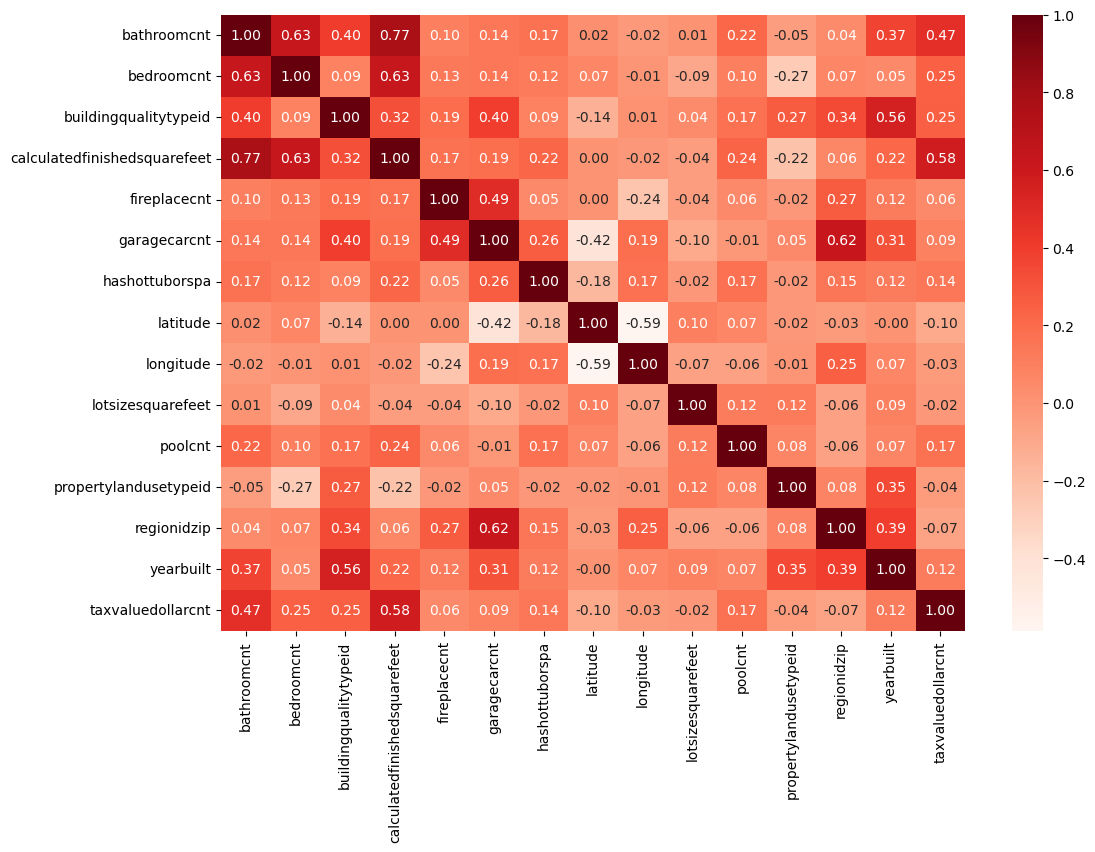

In [193]:
# Running correlation in matrix on non encoded dataset since one hot encoded variables are not useful for looking at correlations
corrs = df_imputed.corr()

X = df_imputed.drop(columns='taxvaluedollarcnt')
y = df_imputed['taxvaluedollarcnt']

plt.figure(figsize=(12,8))
sns.heatmap(corrs, cmap='Reds', annot=True, fmt='.2f')

plt.show()

In [194]:
def plot_f_stats(X,y):
    f_stats, p_values = f_regression(X,y)
    
    f_stat_df = pd.DataFrame({
    'Feature': X.columns,
    'f-stat': f_stats
    }).sort_values('f-stat', ascending=False)
    
    plt.figure(figsize=(10, 6))
    plt.barh(f_stat_df['Feature'], f_stat_df['f-stat'])
    plt.xlabel('F-Statistic')
    plt.title('Feature F-Statistics vs Target')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()

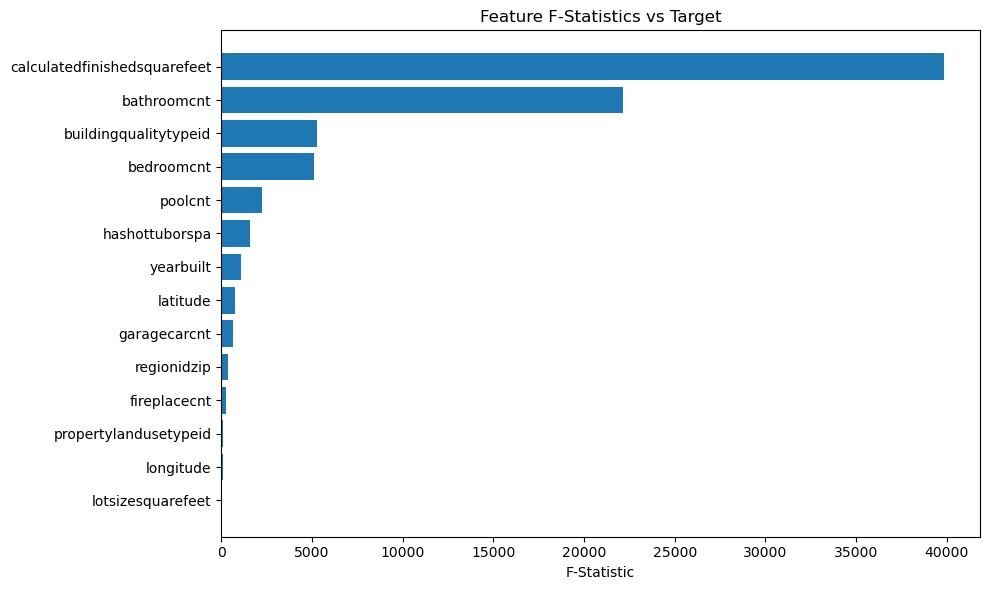

In [195]:
plot_f_stats(X,y)

In [196]:
def forward_feature_selection(X, y, model,
                               scoring='neg_mean_absolute_error',
                               cv=5, n_jobs=-1):
    selected_features = []
    remaining_features = list(X.columns)
    best_scores = []
    best_score = float('inf')
    best_feature_set = None

    while remaining_features:
        scores = {}
        for feature in remaining_features:
            current_features = selected_features + [feature]
            cv_score = -cross_val_score(model, X[current_features], y,
                                        scoring=scoring, cv=cv, n_jobs=n_jobs).mean()
            scores[feature] = cv_score

        best_new = min(scores, key=scores.get)
        selected_features.append(best_new)
        remaining_features.remove(best_new)
        best_scores.append(scores[best_new])

        if scores[best_new] < best_score:
            best_score = scores[best_new]
            best_feature_set = selected_features.copy()

    return selected_features, best_scores, best_feature_set, best_score


def backward_feature_selection(X, y, model,
                                scoring='neg_mean_absolute_error',
                                cv=5, n_jobs=-1):
    def cv_score(features):
        return -cross_val_score(model, X[features], y,
                                scoring=scoring, cv=cv, n_jobs=n_jobs).mean()

    features_remaining = list(X.columns)
    best_score = cv_score(features_remaining)
    best_feature_set = features_remaining.copy()
    removed_features = ['NONE']
    best_scores = [best_score]

    while len(features_remaining) > 1:
        scores = {}
        for feature in features_remaining:
            candidate = [f for f in features_remaining if f != feature]
            scores[feature] = cv_score(candidate)

        worst = min(scores, key=scores.get)
        features_remaining.remove(worst)
        removed_features.append(worst)
        best_scores.append(scores[worst])

        if scores[worst] < best_score:
            best_score = scores[worst]
            best_feature_set = features_remaining.copy()

    return removed_features, best_scores, best_feature_set, best_score


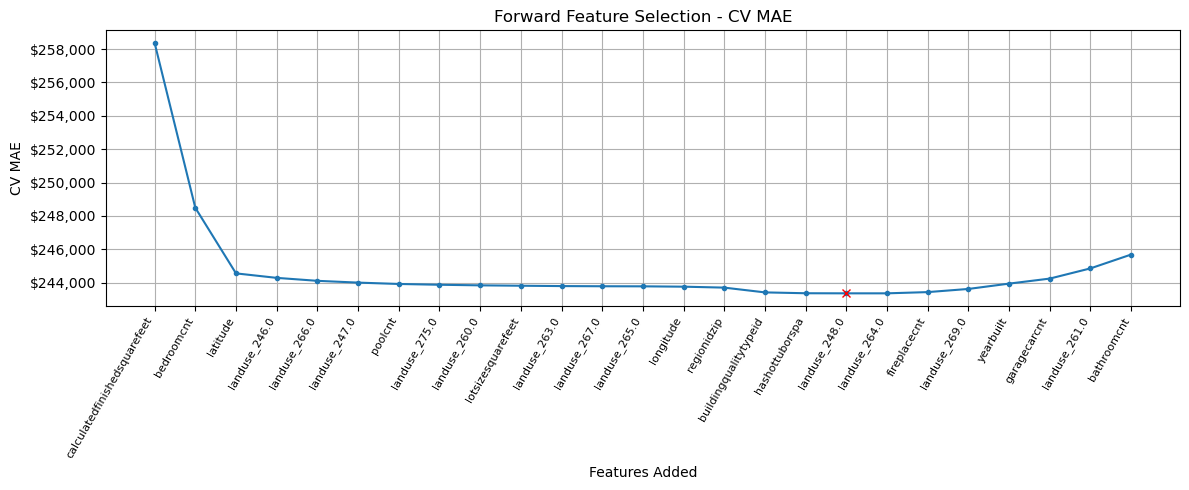

Best Features: ['calculatedfinishedsquarefeet', 'bedroomcnt', 'latitude', 'landuse_246.0', 'landuse_266.0', 'landuse_247.0', 'poolcnt', 'landuse_275.0', 'landuse_260.0', 'lotsizesquarefeet', 'landuse_263.0', 'landuse_267.0', 'landuse_265.0', 'longitude', 'regionidzip', 'buildingqualitytypeid', 'hashottuborspa', 'landuse_248.0']
Best CV MAE: 243356.23


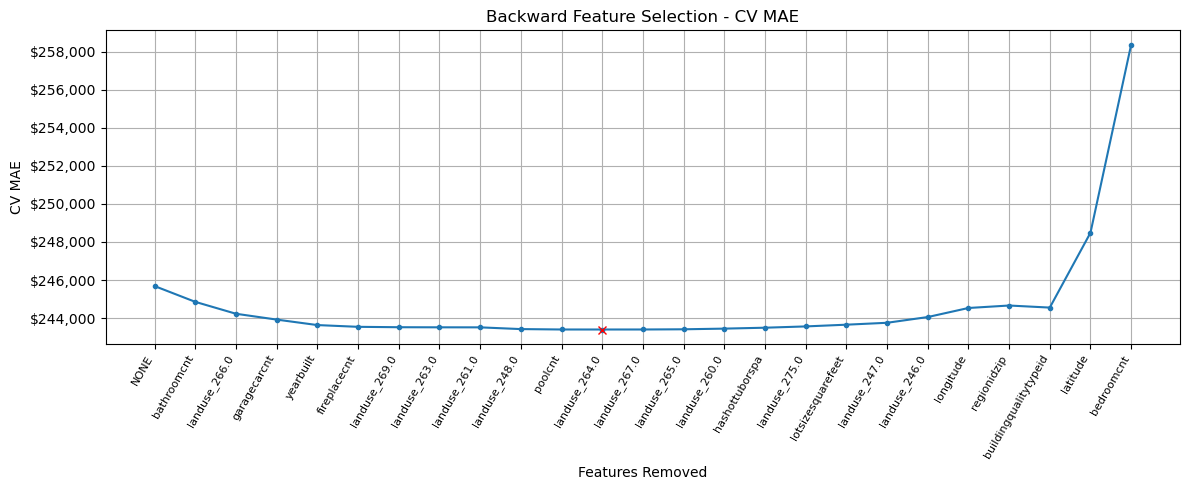

Best Features: ['bedroomcnt', 'buildingqualitytypeid', 'calculatedfinishedsquarefeet', 'hashottuborspa', 'latitude', 'longitude', 'lotsizesquarefeet', 'regionidzip', 'landuse_246.0', 'landuse_247.0', 'landuse_260.0', 'landuse_265.0', 'landuse_267.0', 'landuse_275.0']
Best CV MAE: 243400.78


In [197]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
X = df_encoded.drop(columns='taxvaluedollarcnt')
y = df_encoded['taxvaluedollarcnt']

# Forward
sel_fwd, scores_fwd, best_fwd_features, best_fwd_score = forward_feature_selection(X, y, model)

index = np.argmin(scores_fwd)
plt.figure(figsize=(12, 5))
plt.plot(range(1, len(scores_fwd) + 1), scores_fwd, marker='.')
plt.plot([index + 1], scores_fwd[index], marker='x', color='red')
plt.xticks(range(1, len(sel_fwd) + 1), sel_fwd, rotation=60, ha='right', fontsize=8)
plt.title('Forward Feature Selection - CV MAE')
plt.xlabel('Features Added')
plt.ylabel('CV MAE')
plt.grid()
plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(dollar_format))
plt.tight_layout()
plt.show()

print(f"Best Features: {best_fwd_features}")
print(f"Best CV MAE: {best_fwd_score:.2f}")

# Backward
sel_bwd, scores_bwd, best_bwd_features, best_bwd_score = backward_feature_selection(X, y, model)

index = np.argmin(scores_bwd)
plt.figure(figsize=(12, 5))
plt.plot(range(1, len(scores_bwd) + 1), scores_bwd, marker='.')
plt.plot([index + 1], scores_bwd[index], marker='x', color='red')
plt.xticks(range(1, len(sel_bwd) + 1), sel_bwd, rotation=60, ha='right', fontsize=8)
plt.title('Backward Feature Selection - CV MAE')
plt.xlabel('Features Removed')
plt.ylabel('CV MAE')
plt.grid()
plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(dollar_format))
plt.tight_layout()
plt.show()

print(f"Best Features: {best_bwd_features}")
print(f"Best CV MAE: {best_bwd_score:.2f}")




#### **4.A Discussion:**  Describe in a paragraph what you see in the feature relationships and correlations.

Pay particular attention to especially interesting and/or strongly correlated feature relationships. 
 How do the different methods for seeing relationships compare? Do they agree or disagree?

The strongest predictor seems to be calculatedfinishedsquarefeet with a correlation of .58 with the target and f-stat of ~40,000, which is nearly double the next highest which is bathroomcnt, which is then followed by buildingquality and bedroomcnt. The F-stats and correlation are in agreeance with each other. There are some concerns noted for multicollinearity as calculatedfinishedsquarefeet and bathroomcnt at .77 and bathroomcnt and bedroomcnt at .63. This is expected because a bigger house would naturally have both more bedrooms and bathrooms. Lotsize and propertylanduseid have very little correlation with the target and near 0 f-stats suggesting that they have little predictive power on their own.

### Part 4.B:  2-Dimensional Visualizations for Interesting Patterns  
   - Select three (3) pairs of features that exhibit meaningful relationships based on your previous analysis. 
   - Create 2D scatter plots or density plots to explore interactions between these features.  
   - Provide brief interpretations of any observed patterns or trends. 

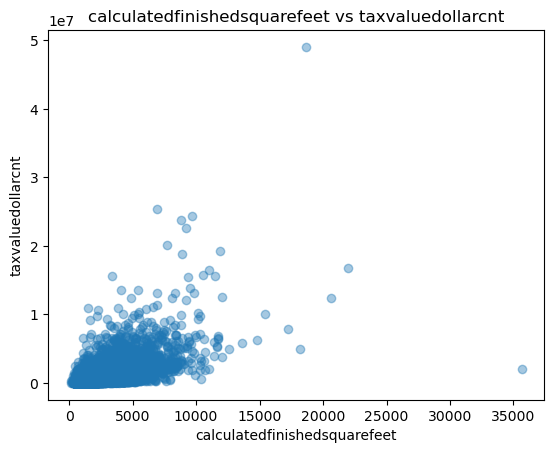

In [198]:
x = df_encoded['calculatedfinishedsquarefeet']
y = df_encoded['taxvaluedollarcnt']
plt.scatter(x,y, alpha=.4)
plt.title(f"{str(x.name)} vs {str(y.name)}")
plt.xlabel(str(x.name))
plt.ylabel(str(y.name))
plt.show()

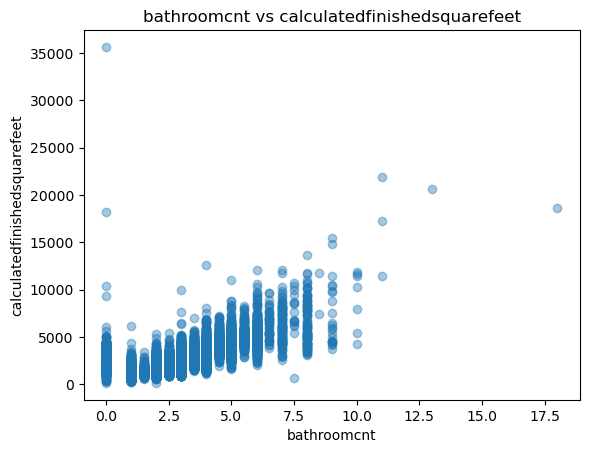

In [199]:
x = df_encoded['bathroomcnt']
y = df_encoded['calculatedfinishedsquarefeet']
plt.scatter(x,y, alpha=.4)
plt.title(f"{str(x.name)} vs {str(y.name)}")
plt.xlabel(str(x.name))
plt.ylabel(str(y.name))
plt.show()

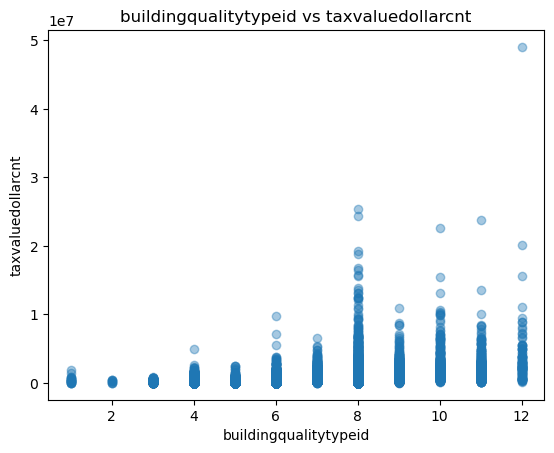

In [200]:
x = df_encoded['buildingqualitytypeid']
y = df_encoded['taxvaluedollarcnt']
plt.scatter(x,y, alpha=.4)
plt.title(f"{str(x.name)} vs {str(y.name)}")
plt.xlabel(str(x.name))
plt.ylabel(str(y.name))
plt.show()

#### **4.B Discussion:** Provide brief interpretations of any observed patterns or trends.

The first scatter shows a positive trend, but as square footage increases, prices tend to spread out rather than staying on a line. This is likely because a few expensive properties tend to pull to the upper right. The second scatter shows a stepped pattern due to discrete values of bathrooms that generally increases. This shows the multicollinearity mentioned earlier that more bathrooms tends to mean larger square footage (or vice versa). The last scatter shows no clear trend - high quality properties span a large price range, although low quality properties do tend to be cheaper it seems.

## Part 5:  Feature Engineering: Investigate various transformations to better expose the underlying data patterns to machine learning algorithms. [6 pts]

**Important Notes:**  
- This last part is a bit open ended, since there is a huge variety of feature engineering techniques, most of which won't be useful for your particular dataset. 
- Understand that you can't evaluate the final usefulness of these transformations
until you choose a model, and  models may respond differently to various transformations or obviate some transformations (e.g., ensemble methods already do feature selection). 
- Therefore, write your transformations as functions or otherwise be prepared
to choose later on which transformations may be necessary. 

**Investigate feature engineering, where appropriate:**

- Feature scaling: standardize or normalize features as necessary
- Decompose features (e.g., categorical into One-Hot feature sequence, date/time into two features data and time, etc.).
- Add promising transformations of features
    - Exponential $\exp(x_i)$ or logarithmic $\log(x_j)$
    - Polynomial features  ( $x_i^2$, $x_i - x_j$), products ($x_i*x_j$), or ratios ($x_i/x_j$)

**ToDo:**
- Pick at least three transformations to try.
- Try each one and evaluate its effect using correlations or F-scores or a feature selection algorithm.
- Answer the discussion question. 

In [201]:
#log transform target
def compare_target_transformation(df, target_col, transform):
    df = df.copy()
    
    transformed_col = f"transformed_{target_col}"
    
    df[transformed_col] = transform(df[target_col])

    features = df.drop(columns=[target_col, transformed_col])

    raw_corr = features.corrwith(df[target_col])
    transformed_corr = features.corrwith(df[transformed_col])

    return pd.DataFrame({
        "Raw Correlation":          raw_corr,
        "Transformed Correlation":  transformed_corr,
        "Difference":               transformed_corr-raw_corr
    }).sort_values("Difference", ascending=False).round(3)


In [202]:
target = 'taxvaluedollarcnt'
compare_target_transformation(df_imputed, target, transform=np.log1p)

,Raw Correlation,Transformed Correlation,Difference
yearbuilt,0.119,0.252,0.133
buildingqualitytypeid,0.253,0.347,0.094
garagecarcnt,0.091,0.174,0.082
fireplacecnt,0.057,0.113,0.056
regionidzip,-0.067,-0.026,0.041
propertylandusetypeid,-0.036,0.003,0.039
bathroomcnt,0.472,0.486,0.014
hashottuborspa,0.143,0.157,0.014
longitude,-0.033,-0.020,0.013
bedroomcnt,0.249,0.259,0.011


In [203]:
#compare log transform of lotsize and compare correlation with target
def compare_feature_transformation(df, feature_col, target_col, transform):
    raw_corr = df[feature_col].corr(df[target_col])
    transformed_corr = transform(df[feature_col]).corr(df[target_col])
    
    return pd.Series({
        'Raw Correlation':         raw_corr,
        'Transformed Correlation': transformed_corr,
        'Difference':              transformed_corr - raw_corr
    }).round(3)

compare_feature_transformation(df_imputed, 'calculatedfinishedsquarefeet', 'taxvaluedollarcnt', np.log1p)


Raw Correlation            0.583
Transformed Correlation    0.468
Difference                -0.115
dtype: float64

In [204]:
#compare total rooms (bedrooms + bathrooms) with target variable correlation
def compare_combined_feature(df, feature_cols, target_col, combine_func):

    raw_corrs = {col: df[col].corr(df[target_col]) for col in feature_cols}
    
    combined = combine_func(*[df[c] for c in feature_cols])
    combined_corr = combined.corr(df[target_col])
    
    results = {f'Raw: {col}': corr for col, corr in raw_corrs.items()}
    results['Combined'] = combined_corr
    
    return pd.Series(results).round(3)

compare_combined_feature(df_imputed, ['bedroomcnt', 'bathroomcnt'], 'taxvaluedollarcnt', combine_func=lambda a, b: a + b)

Raw: bedroomcnt     0.249
Raw: bathroomcnt    0.472
Combined            0.391
dtype: float64

In [205]:
#zip code first 3 digits to isolate the region - makes less unique values
zip_col = 'regionidzip'
compare_feature_transformation(df_imputed, zip_col, target, transform=lambda x: x.astype(int)//100)

Raw Correlation           -0.067
Transformed Correlation   -0.069
Difference                -0.002
dtype: float64

In [209]:
def make_binary_cols(df, cols):
    df = df.copy()
    for col in cols:
        df[f'has_{col}'] = (df[col] > 0).astype(int)
        df = df.drop(columns=col)
    return df

In [ ]:
cols_to_make_binary = ['fireplacecnt', 'garagecarcnt', 'hashottuborspa', 'poolcnt']

print("Before:")
print(df_imputed[cols_to_make_binary].corrwith(df_imputed['taxvaluedollarcnt']).round(3))

df_binarized = make_binary_cols(df_imputed, cols_to_make_binary)
print("\nAfter:")
print(df_binarized[['has_fireplacecnt', 'has_garagecarcnt', 'has_hashottuborspa', 'has_poolcnt']].corrwith(df_imputed['taxvaluedollarcnt']).round(3))


Before:
fireplacecnt      0.057
garagecarcnt      0.091
hashottuborspa    0.143
poolcnt           0.168
dtype: float64

After:
has_fireplacecnt      0.019
has_garagecarcnt      0.037
has_hashottuborspa    0.143
has_poolcnt           0.168
dtype: float64


#### **5 Discussion:** Describe in a paragraph why you chose these transformations and what you observed. 

I did a log transform on the target variable since it exhibited a right skew due to extremely high valued properties. A log transformation can make the distribution more symmetric, which can be beneficial for models that assume the data is normally distributed such as a linear regression. In transforming the target variable, the correlation with almost all of the features increased, which shows that this may be a good feature enginerring step. For the same reasoning, I tried a log transformation on the calculatedfinishedsquare feet for the same reasons as above, although this showed a decrease in the correlation with the target - it is possible that they should be both log transformed at the same time.

I also tried combining the number of rooms (bathroom + bedrooms) since these two are highly correalted they might cause some multicollinearity issues when modeling. However, when combing them, the correlation was worse than just looking at the bathoom alone. It might be worth droppping bedrooms as a feature since it does not correlate with the target very strongly.

I tried extracting the first three digits of the zip code, because this incdicates a specific region, and would reduce the number of unique values. However, it made almost no difference in the correlation, and in general the zip code shows no meaningul linear relationship with the target, higher numbers do not correlate with a more expensive area, and it may be worth dropping the zip

I tried making some columns binary - instead of garagecarcnt for example, I made it a simple has_garage binary variable, however this weakened its correlation indicating that the number of cars in garage is meaningful. I did the same with pool count and hot tub count but the correlation was the same indicating the feature was already binary.


## **Appendix 1: Features of the Zillow Dataset**  

0. **parcelid**: Unique identifier for the property parcel.  
1. **airconditioningtypeid**: Identifier for the type of air conditioning installed.  
2. **architecturalstyletypeid**: Identifier for the architectural style of the property.  
3. **basementsqft**: Square footage of the basement.  
4. **bathroomcnt**: Number of bathrooms.  
5. **bedroomcnt**: Number of bedrooms.  
6. **buildingclasstypeid**: Identifier for the building framing type (e.g., wood frame, steel frame).  
7. **buildingqualitytypeid**: Numeric value indicating the quality of the building (higher values often indicate better quality).  
8. **calculatedbathnbr**: Calculated number of bathrooms, including fractional bathrooms.  
9. **decktypeid**: Identifier for the type of deck.  
10. **finishedfloor1squarefeet**: Square footage of the finished area on the first floor.  
11. **calculatedfinishedsquarefeet**: Total finished living area square footage.  
12. **finishedsquarefeet12**: Finished living area square footage.  
13. **finishedsquarefeet13**: Perimeter living area square footage.  
14. **finishedsquarefeet15**: Total area.  
15. **finishedsquarefeet50**: Square footage of the finished area on the upper floors.  
16. **finishedsquarefeet6**: Base unfinished and finished area square footage.  
17. **fips**: Federal Information Processing Standards code, uniquely identifying counties and county equivalents.  
18. **fireplacecnt**: Number of fireplaces.  
19. **fullbathcnt**: Number of full bathrooms.  
20. **garagecarcnt**: Number of cars that can fit in the garage.  
21. **garagetotalsqft**: Total square footage of the garage.  
22. **hashottuborspa**: Indicates if the property has a hot tub or spa.  
23. **heatingorsystemtypeid**: Identifier for the type of heating system.  
24. **latitude**: Latitude coordinate of the property.  
25. **longitude**: Longitude coordinate of the property.  
26. **lotsizesquarefeet**: Lot size in square feet.  
27. **poolcnt**: Number of pools on the property.  
28. **poolsizesum**: Total square footage of all pools.  
29. **pooltypeid10**: Identifier for spa or hot tub.  
30. **pooltypeid2**: Identifier for pool with spa or hot tub.  
31. **pooltypeid7**: Identifier for pool without hot tub or spa.  
32. **propertycountylandusecode**: County land use code for the property.  
33. **propertylandusetypeid**: Identifier for the property land use type.  
34. **propertyzoningdesc**: Description of the property's zoning.  
35. **rawcensustractandblock**: Unprocessed census tract and block identifier.  
36. **regionidcity**: Identifier for the city.  
37. **regionidcounty**: Identifier for the county.  
38. **regionidneighborhood**: Identifier for the neighborhood.  
39. **regionidzip**: Identifier for the ZIP code.  
40. **roomcnt**: Total number of rooms.  
41. **storytypeid**: Identifier for the type of stories in the building (e.g., basement, attic).  
42. **threequarterbathnbr**: Number of 3/4 bathrooms (typically includes a shower but no tub).  
43. **typeconstructiontypeid**: Identifier for the type of construction (e.g., frame, masonry).  
44. **unitcnt**: Number of units in the building (e.g., for multi-family properties).  
45. **yardbuildingsqft17**: Square footage of the 17th yard building (e.g., shed).  
46. **yardbuildingsqft26**: Square footage of the 26th yard building.  
47. **yearbuilt**: Year the property was built.  
48. **numberofstories**: Number of stories in the building.  
49. **fireplaceflag**: Indicates if the property has a fireplace.  
50. **assessmentyear**: Year the property was assessed.  
51. **taxdelinquencyflag**: Indicates whether the property’s taxes are delinquent. Often “Y” if taxes are past due; otherwise null/empty.  
52. **taxdelinquencyyear**: The year in which the property’s taxes became delinquent.  
53. **censustractandblock**: A combined identifier for the property’s census tract and block group (part of the U.S. Census geographic hierarchy).  
54. **taxvaluedollarcnt**: Total assessed value of the property (land plus structure) in dollars.  


## Appendix 2: Summary of Basic Imputation Methods
Imputation depends on the data type and context. Below are common techniques for handling missing values.

---

### **1. Simple Imputation (Basic Methods)**
| Method | Best For | Code Example | Pros | Cons |
|--------|---------|--------------|------|------|
| **Drop Missing Values** | Few missing values (<5% of data) | `df.dropna()` | Quick and easy | Can remove valuable data |
| **Mean Imputation** | Normally distributed numerical data | `df.fillna(df.mean())` | Preserves mean; simple | Distorts variance, weak for skewed data |
| **Median Imputation** | Skewed numerical data | `df.fillna(df.median())` | Robust to outliers | May not capture patterns |
| **Mode Imputation** | Categorical features | `df.fillna(df.mode().iloc[0])` | Keeps most common category | Can introduce bias |
| **Constant Value (e.g., 0)** | Special cases (e.g., unknown numerical data) | `df.fillna(0)` | Simple and interpretable | Can mislead model |
| **"Unknown" Category Imputation** (**New Addition**) | Categorical features with missing values | `df.fillna('Unknown')` | Keeps all rows, prevents data loss | May introduce artificial category |

---

### **2. Statistical & Advanced Imputation**
| Method | Best For | Code Example | Pros | Cons |
|--------|---------|--------------|------|------|
| **Interpolation** | Time series, ordered data | `df.interpolate(method='linear')` | Preserves trends | May not work for non-continuous data |
| **K-Nearest Neighbors (KNN)** | Small datasets, patterns in features | `KNNImputer(n_neighbors=5).fit_transform(df)` | Uses similar observations | Computationally expensive |
| **Multivariate Imputation (MICE)** | Complex relationships between variables | `IterativeImputer().fit_transform(df)` | Captures relationships | Slower than mean/median |
| **Regression Imputation** | When missing values depend on other variables | Train regression model to predict missing values | More accurate than mean/median | Risk of overfitting |

---

### **When to Use "Unknown" Category for Categorical Imputation**
✅ **Good for:**
- Categorical features where missing values may indicate meaningful differences.  
- Customer data (e.g., missing survey responses → "No Response").  
- Product categories where missing could be a separate group.  

❌ **Avoid if:**
- The missing category does **not** have a meaningful interpretation.
- The model might learn spurious patterns from an artificial category.

---

### **Which Method to Choose?**
| Scenario | Best Method |
|----------|------------|
| **Few missing values (<5%)** | Drop NaNs (`df.dropna()`) |
| **Numerical & normal distribution** | Mean (`df.fillna(df.mean())`) |
| **Numerical & skewed distribution** | Median (`df.fillna(df.median())`) |
| **Categorical features** | Mode (`df.fillna(df.mode().iloc[0])`) |
| **Categorical with possible meaning in missingness** | "Unknown" Category (`df.fillna('Unknown')`) |
| **Small dataset with patterns** | KNN Imputer (`KNNImputer()`) |
| **Complex relationships between features** | MICE / Iterative Imputer |

